# 📐 이미지 데이터 연동 및 기하학적 시공간 물리 분석 (OWL-ViT & Soft Prompting)

본 노트북은 비디오 프레임 순서 정렬 과제에서 발생할 수 있는 규칙 기반 하드코딩(Hard-coding)과 도메인 과적합(Overfitting) 문제를 원천 차단하고, **객체의 물리적 기하학(Pure Geometry) 정보**와 **VLM의 의미론적 맥락 이해력**을 결합하여 정렬 정확도를 극대화하는 최종 검증용 EDA 노트북입니다.

### 핵심 연동 설계:
1. **기하학적 공간 특징 추출 (OWL-ViT)**: Open-Vocabulary 객체 탐지를 이용하여 $X, Y$ 중심 좌표 및 화면 점유 면적 비율($R_{bbox} = \text{객체 면적} / \text{이미지 면적}$)을 추출합니다. (단안 깊이 모델의 오프셋 왜곡 극복)
2. **Max Area Filter**: 동일 클래스의 여러 객체가 감지될 경우, 화면을 가장 크게 점유하는 메인 피사체로 일관성 있게 고정합니다.
3. **결측치 마스킹 (Masking)**: 강제 선형 보간 대신 검출 실패 프레임에 대해 명시적 Skip 플래그를 할당하여 에러 전파 및 폴백 좌표로 인한 오판을 차단합니다.
4. **가중치 코사인 정렬 (Text Embedding Aligner)**: 캡션 문장의 뉘앙스와 'Depth/Trajectory' 두 기준 축(Anchor Axis)의 코사인 유사도를 연산하여 VLM에 신뢰도 가이드를 Soft Prompt 형태로 주입합니다.

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn.functional as F
import re

# PyTorch 중복 라이브러리 경고 방지
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

try:
    from transformers import OwlViTProcessor, OwlViTForObjectDetection
    HAS_OWL = True
    print('✅ OWL-ViT (transformers) 로드 성공!')
except ImportError:
    HAS_OWL = False
    print('⚠️ \"transformers\" 라이브러리가 없습니다. 데모용 Mock 클래스로 대체됩니다. 설치: !pip install transformers')

try:
    from transformers import CLIPProcessor, CLIPModel
    HAS_CLIP = True
    print('✅ CLIP (transformers) 로드 성공!')
except ImportError:
    HAS_CLIP = False
    print('⚠️ CLIP 라이브러리가 없습니다. 데모용 Mock 클래스로 대체됩니다.')

# OWL-ViT 라이브러리가 없을 때 데모 실행이 가능하도록 모의(Mock) 클래스 작성
if not HAS_OWL:
    class MockOwlViT:
        def __init__(self, *args, **kwargs):
            pass
        def eval(self):
            pass
        def to(self, device):
            return self
            
    class MockProcessor:
        @classmethod
        def from_pretrained(cls, name):
            return cls()
        def __call__(self, text, images, **kwargs):
            return {}
        def post_process_object_detection(self, outputs, target_sizes, threshold):
            h, w = target_sizes[0].tolist()
            mock_boxes = np.array([[w*0.2, h*0.2, w*0.8, h*0.8]])
            return [{
                'boxes': torch.tensor(mock_boxes),
                'scores': torch.tensor([0.95]),
                'labels': torch.tensor([0])
            }]
            
    OwlViTProcessor = MockProcessor
    OwlViTForObjectDetection = MockOwlViT
    print('ℹ️ 오프라인 구동 및 테스트를 위해 Mock OWL-ViT 모듈이 로드되었습니다.')

# CLIP 라이브러리가 없을 때 데모 실행이 가능하도록 모의(Mock) 클래스 작성
if not HAS_CLIP:
    class MockCLIP:
        def __init__(self, *args, **kwargs):
            pass
        def eval(self):
            pass
        def to(self, device):
            return self
            
    class MockCLIPProcessor:
        @classmethod
        def from_pretrained(cls, name):
            return cls()
        def __call__(self, images, **kwargs):
            return {}
            
    CLIPProcessor = MockCLIPProcessor
    CLIPModel = MockCLIP
    print('ℹ️ 오프라인 구동 및 테스트를 위해 Mock CLIP 모듈이 로드되었습니다.')

✅ OWL-ViT (transformers) 로드 성공!
✅ CLIP (transformers) 로드 성공!


## 1. 텍스트 임베딩 기반 가중치 얼라이너 (Text Embedding Aligner)

캡션 문장의 뉘앙스에 따라 '공간적 깊이(Depth)'와 '평면적 이동(Trajectory)' 중 어떤 분석 도구를 더 신뢰할지 수학적으로 자동 가중치를 배분합니다. 
오프라인 환경을 위해 허깅페이스 모델이 없을 경우 단어 벡터 기반의 Cosine Similarity 연산으로 동작하는 폴백을 내장합니다.

In [53]:
class TextEmbeddingAligner:
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2", device="cpu"):
        self.device = device
        self.has_model = False
        try:
            from transformers import AutoTokenizer, AutoModel
            self.tokenizer = AutoTokenizer.from_pretrained(model_name)
            self.model = AutoModel.from_pretrained(model_name).to(self.device)
            self.model.eval()
            self.has_model = True
            print("✅ Sentence-Transformer 모델 로드 성공!")
        except Exception:
            print("ℹ️ 오프라인 상태 혹은 모델이 없습니다. Bag-of-Words 임베딩 폴백을 사용합니다.")
            
        # 3D 깊이와 2D 궤적 의미를 지닌 기준 단어(Anchor Word) 정의
        self.depth_anchors = ["zooms in", "zooms out", "closer", "further", "distant", "approaching", "receding", "가까워짐", "멀어짐", "다가옴", "줌인", "줌아웃", "클로즈업"]
        self.trajectory_anchors = ["moves left", "moves right", "raises higher", "falls down", "shifts left", "shifts right", "오른쪽", "왼쪽", "위로", "아래로", "이동", "상하", "좌우"]

    def get_embedding(self, text):
        """
        텍스트의 임베딩 벡터를 추출하여 정규화합니다.
        """
        if self.has_model:
            from transformers import AutoTokenizer, AutoModel
            inputs = self.tokenizer(text, padding=True, truncation=True, return_tensors="pt").to(self.device)
            with torch.no_grad():
                outputs = self.model(**inputs)
            # Mean Pooling
            embeddings = outputs.last_hidden_state.mean(dim=1)
            return embeddings / embeddings.norm(dim=-1, keepdim=True)
        else:
            # Bag-of-Words 기반 단어 매핑 가상 임베딩 벡터 생성
            vocab = list(set(self.depth_anchors + self.trajectory_anchors))
            words = text.lower().split()
            vec = np.zeros(len(vocab))
            for w in words:
                for idx, anchor in enumerate(vocab):
                    if anchor in w or w in anchor:
                        vec[idx] += 1.0
            norm = np.linalg.norm(vec)
            if norm > 0:
                vec = vec / norm
            return torch.tensor([vec], dtype=torch.float32)

    def calculate_weights(self, caption):
        """
        캡션과 두 기준 축(Depth, Trajectory) 간의 코사인 유사도를 계산하고 소프트맥스 가중치를 반환합니다.
        """
        caption_vec = self.get_embedding(caption)
        
        # 각 기준 축의 가상 캡션 벡터 생성
        depth_vec = self.get_embedding(" ".join(self.depth_anchors))
        traj_vec = self.get_embedding(" ".join(self.trajectory_anchors))
        
        # 코사인 유사도 계산
        cos_depth = F.cosine_similarity(caption_vec, depth_vec).item()
        cos_traj = F.cosine_similarity(caption_vec, traj_vec).item()
        
        # 대비 극대화를 위해 스케일 업 후 Softmax 연산
        exp_d = np.exp(cos_depth * 5.0)
        exp_t = np.exp(cos_traj * 5.0)
        sum_exp = exp_d + exp_t
        
        w_depth = exp_d / sum_exp
        w_traj = exp_t / sum_exp
        
        return w_depth, w_traj, cos_depth, cos_traj

# 모듈 동작 확인
aligner = TextEmbeddingAligner()
w_d, w_t, c_d, c_t = aligner.calculate_weights("A person shifts closer to the camera.")
print(f"가중치 배분 결과 - Depth 신뢰도: {w_d:.2f}, Trajectory 신뢰도: {w_t:.2f} (유사도: D={c_d:.2f}, T={c_t:.2f})")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8587.71it/s]

✅ Sentence-Transformer 모델 로드 성공!
가중치 배분 결과 - Depth 신뢰도: 0.65, Trajectory 신뢰도: 0.35 (유사도: D=0.45, T=0.33)


## 2. OWL-ViT 기하학적 시공간 물리 분석기 (Spatial3DOwlViTTrajectoryExtractor)

OWL-ViT로 사물 바운딩 박스를 검출하고, 획득한 좌표 정보를 통해 3D 공간을 정의합니다. 
하드코딩 및 도메인 과적합을 방지하기 위해, 오직 BBox의 기하학적 좌표($X, Y, Area$)만 추출하고 결측치는 선형 보간 대신 마스킹(Masking)하여 배제합니다.

In [54]:
def extract_candidate_nouns(caption):
    '''
    캡션에서 불용어를 제외하고 의미 있는 영어 단어 후보들을 명사 후보군으로 단순 추출합니다.
    '''
    clean_caption = re.sub(r'[^\w\s]', '', caption.lower())
    words = clean_caption.split()
    
    stopwords = {
        'a', 'an', 'the', 'in', 'on', 'at', 'with', 'by', 'to', 'of', 'for', 'and', 'or', 'but',
        'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did',
        'this', 'that', 'these', 'those', 'then', 'there', 'here', 'it', 'its', 'they', 'them', 'their',
        'he', 'him', 'his', 'she', 'her', 'we', 'us', 'our', 'you', 'your', 'moves', 'shifts', 'zooms',
        'closer', 'further', 'away', 'closer', 'into', 'out', 'up', 'down', 'left', 'right', 'closer'
    }
    
    candidates = [w for w in words if w not in stopwords and len(w) > 2]
    candidates = list(set(candidates))
    if 'person' not in candidates:
        candidates.append('person')
    return candidates

class Spatial3DOwlViTTrajectoryExtractor:
    def __init__(self, model_name='google/owlvit-base-patch32', device='cpu'):
        self.device = device
        if HAS_OWL:
            self.processor = OwlViTProcessor.from_pretrained(model_name)
            self.model = OwlViTForObjectDetection.from_pretrained(model_name).to(device)
            self.model.eval()
        else:
            self.processor = OwlViTProcessor.from_pretrained(model_name)
            self.model = OwlViTForObjectDetection()
        
    def extract_3d_spatial_features(self, image_paths, query_text):
        '''
        4장의 이미지와 검색 대상 Open-Vocabulary 쿼리 텍스트를 이용하여 X, Y 궤적 및 면적 변화 비율을 통합 추출합니다.
        '''
        results_summary = []
        text_queries = [[query_text]]
        
        for idx, img_path in enumerate(image_paths):
            if not os.path.exists(img_path):
                results_summary.append({
                    'frame': idx + 1,
                    'status': 'file_not_found',
                    'bbox': None,
                    'center': None,
                    'area_ratio': 0.0,
                    'score': 0.0
                })
                continue
                
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            img_area = w * h
            
            if HAS_OWL:
                inputs = self.processor(text=text_queries, images=img, return_tensors='pt')
                inputs = {k: v.to(self.device) for k, v in inputs.items()}
                with torch.no_grad():
                    outputs = self.model(**inputs)
                target_sizes = torch.tensor([img.size[::-1]], dtype=torch.float32).to(self.device)
                
                if hasattr(self.processor, 'post_process_object_detection'):
                    results = self.processor.post_process_object_detection(
                        outputs=outputs, target_sizes=target_sizes, threshold=0.05
                    )[0]
                else:
                    results = self.processor.image_processor.post_process_object_detection(
                        outputs=outputs, target_sizes=target_sizes, threshold=0.05
                    )[0]
                    
                boxes = results['boxes'].cpu().numpy()
                scores = results['scores'].cpu().numpy()
            else:
                mock_boxes_list = [
                    [w*0.4, h*0.4, w*0.6, h*0.6],
                    [w*0.35, h*0.35, w*0.65, h*0.65],
                    [w*0.3, h*0.3, w*0.7, h*0.7],
                    [w*0.2, h*0.2, w*0.8, h*0.8]
                ]
                boxes = np.array([mock_boxes_list[idx]])
                scores = np.array([0.95])
            
            if len(boxes) == 0:
                results_summary.append({
                    'frame': idx + 1,
                    'status': 'missed_detection',
                    'bbox': None,
                    'center': None,
                    'area_ratio': 0.0,
                    'score': 0.0
                })
                continue
                
            best_idx = 0
            max_area = 0
            for i, box in enumerate(boxes):
                box_w = box[2] - box[0]
                box_h = box[3] - box[1]
                area = box_w * box_h
                if area > max_area:
                    max_area = area
                    best_idx = i
            
            best_box = boxes[best_idx]
            best_score = scores[best_idx] if len(scores) > best_idx else 0.5
            x1, y1, x2, y2 = map(int, best_box)
            
            cx = ((x1 + x2) / 2) / w
            cy = ((y1 + y2) / 2) / h
            best_area_ratio = max_area / img_area
            
            results_summary.append({
                'frame': idx + 1,
                'status': 'success',
                'bbox': (x1, y1, x2, y2),
                'center': (cx, cy),
                'area_ratio': best_area_ratio,
                'score': best_score
            })
            
        return results_summary

    def select_best_query(self, image_paths, candidate_queries):
        '''
        추출된 후보 단어들을 각각 OWL-ViT에 대입하여 4개 프레임에 걸친 평균 탐지 신뢰도(Confidence Score)를 측정하고,
        가장 신뢰도가 높은 명사를 최종 query_text로 자동 채택합니다.
        '''
        best_query = 'person'
        max_avg_score = -1.0
        query_scores = {}
        
        for q in candidate_queries:
            features = self.extract_3d_spatial_features(image_paths, q)
            scores = [f['score'] for f in features if f['status'] == 'success']
            if len(scores) > 0:
                avg_score = sum(scores) / len(image_paths)
            else:
                avg_score = 0.0
            
            query_scores[q] = avg_score
            if avg_score > max_avg_score:
                max_avg_score = avg_score
                best_query = q
                
        return best_query, query_scores

class CLIPSceneDivider:
    def __init__(self, model_name='openai/clip-vit-base-patch32', device='cpu'):
        self.device = device
        if HAS_CLIP:
            self.processor = CLIPProcessor.from_pretrained(model_name)
            self.model = CLIPModel.from_pretrained(model_name).to(device)
            self.model.eval()
        else:
            self.processor = CLIPProcessor()
            self.model = CLIPModel()
            
    def analyze_cuts(self, image_paths, threshold=0.85):
        '''
        4장의 이미지 간의 CLIP 유사도를 분석하여 장면 전환(Cut) 경계를 찾아내고 씬 그룹을 반환합니다.
        '''
        scene_groups = []
        similarities = []
        
        imgs = []
        for path in image_paths:
            if os.path.exists(path):
                imgs.append(Image.open(path).convert('RGB'))
            else:
                imgs.append(Image.new('RGB', (100, 100)))
                
        if HAS_CLIP:
            inputs = self.processor(images=imgs, return_tensors='pt')
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = self.model.get_image_features(**inputs)
            
            if not isinstance(outputs, torch.Tensor):
                if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                    image_features = outputs.pooler_output
                elif hasattr(outputs, 'image_embeds') and outputs.image_embeds is not None:
                    image_features = outputs.image_embeds
                else:
                    image_features = outputs[0]
            else:
                image_features = outputs
                
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            
            for i in range(len(imgs) - 1):
                sim = torch.dot(image_features[i], image_features[i+1]).item()
                similarities.append(sim)
        else:
            similarities = [0.95, 0.70, 0.92]
            
        current_group = [1]
        for idx, sim in enumerate(similarities):
            frame_id = idx + 2
            if sim < threshold:
                scene_groups.append(current_group)
                current_group = [frame_id]
            else:
                current_group.append(frame_id)
        scene_groups.append(current_group)
        
        return scene_groups, similarities

## 3. VLM 주입용 기하학 보조 힌트 빌더

추출기 데이터를 텍스트 가중치와 매핑하여 최종 Qwen2-VL이 받아볼 형태의 가이드를 생성합니다. 결측치가 존재할 경우 Masking 처리하여 정렬 대상에서 자동 배제하는 로직이 적용됩니다.

In [55]:
def build_3d_spatial_auxiliary_hint(image_paths, sentence, query_text=None):
    '''
    임베딩 코사인 정렬을 통한 가중치 배분 및 CLIP 씬 분리, OWL-ViT 자동 쿼리 선택 기반의
    고도화된 기하학적 데이터 힌트 텍스트를 완성합니다.
    '''
    aligner = TextEmbeddingAligner()
    w_depth, w_traj, cos_depth, cos_traj = aligner.calculate_weights(sentence)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    extractor = Spatial3DOwlViTTrajectoryExtractor(device=device)
    
    candidate_queries = extract_candidate_nouns(sentence)
    if query_text is not None and query_text not in candidate_queries:
        candidate_queries.append(query_text)
        
    best_query, query_scores = extractor.select_best_query(image_paths, candidate_queries)
    features = extractor.extract_3d_spatial_features(image_paths, best_query)
    
    divider = CLIPSceneDivider(device=device)
    scene_groups, similarities = divider.analyze_cuts(image_paths)
    
    hints = []
    hints.append('[시각 분석 보조 시스템 기하학적 시공간 힌트]')
    hints.append('4장의 뒤섞인 이미지와 자연어 캡션을 대조하여 올바른 프레임 순서를 추론하세요.\n')
    
    hints.append(f'- 캡션 가중치 배분 (임베딩 앵커 코사인 정렬):')
    hints.append(f'  * 깊이 방향 유사도 (Depth Match): {cos_depth:.2f}')
    hints.append(f'  * 평면 궤적 유사도 (Trajectory Match): {cos_traj:.2f}')
    
    recom_axis = '깊이 변화 흐름[주인공의 화면 점유 비율 변화]' if w_depth > w_traj else '평면 궤적 변화[좌우/상하 이동]'
    hints.append(f'  * (시스템 추천: {recom_axis}에 더 큰 가중치를 두어 순서를 정렬하세요.)\n')
    
    hints.append(f'- 장면 분할 정보 (CLIP 인접 유사도: {[round(s, 2) for s in similarities]}):')
    scene_strs = [f'Group {i+1} [Image ' + ', '.join([str(fid) for fid in g]) + ']' for i, g in enumerate(scene_groups)]
    hints.append(f'  * 검출된 장면 그룹: ' + ' / '.join(scene_strs))
    hints.append(f'  * (동일 장면 그룹 내에서만 연속적인 움직임이나 줌 변화 추세를 관찰해야 오판을 막을 수 있습니다.)\n')
    
    hints.append(f'- 핵심 피사체 쿼리 자동 채택 (OWL-ViT):')
    hints.append(f'  * 추출된 캡션 단어 후보군: {candidate_queries}')
    hints.append(f'  * 최종 채택된 쿼리: \'{best_query}\' (평균 검출 신뢰도: {query_scores[best_query]:.3f})')
    hints.append(f'  * 쿼리별 신뢰도 순위: {sorted(query_scores.items(), key=lambda x: x[1], reverse=True)}\n')
    
    hints.append(f'- 물리 측정 데이터 (OWL-ViT - Target: \'{best_query}\'):')
    
    valid_frames = []
    for idx, f in enumerate(features):
        frame_id = f['frame']
        if f['status'] == 'success':
            cx, cy = f['center']
            area = f['area_ratio'] * 100
            
            if len(image_paths) == 4 and not os.path.exists(image_paths[0]):
                mock_areas = [31.4, 18.2, 11.5, 5.0]
                area = mock_areas[idx]
                
            hints.append(f'  * Image {frame_id}: \'{best_query}\' center=[X={cx:.3f}, Y={cy:.3f}], Area={area:.1f}%')
            valid_frames.append((frame_id, area))
        else:
            hints.append(f'  * Image {frame_id}: \'{best_query}\' - no object detected (skip this cue)')
            
    if len(valid_frames) >= 2:
        sorted_frames = sorted(valid_frames, key=lambda x: x[1])
        
        hints.append(f'\n[최종 정렬 가이드]')
        hints.append(f'만약 캡션에 피사체가 가까워지거나(Zoom-in) 멀어지는(Zoom-out) 물리적 묘사가 지배적이라면,')
        
        if len(scene_groups) > 1:
            hints.append(f'주의: 여러 장면 그룹({len(scene_groups)}개)이 감지되었습니다.')
            for i, group in enumerate(scene_groups):
                group_valid = [vf for vf in valid_frames if vf[0] in group]
                if len(group_valid) >= 2:
                    sorted_group = sorted(group_valid, key=lambda x: x[1])
                    g_flow = ' -> '.join([f'Image {fid} ({val:.1f}%)' for fid, val in sorted_group])
                    hints.append(f'  * {scene_strs[i]} 내부 면적 흐름: {g_flow}')
        else:
            flow_str = ' -> '.join([f'Image {fid} ({val:.1f}%)' for fid, val in sorted_frames])
            hints.append(f'  * 전체 이미지 면적 흐름: {flow_str}')
            
        # 카메라 수평 패닝(Pan Left/Right) 및 객체 좌우 이동에 대한 인과성 물리 가이드 추가
        s_lower = sentence.lower()
        is_pan_left = 'pan left' in s_lower or 'move left' in s_lower or 'shift left' in s_lower or '왼쪽' in s_lower
        is_pan_right = 'pan right' in s_lower or 'move right' in s_lower or 'shift right' in s_lower or '오른쪽' in s_lower
        valid_x = [(f['frame'], f['center'][0]) for f in features if f['status'] == 'success']
        
        if (is_pan_left or is_pan_right) and len(valid_x) >= 2:
            hints.append(f'또한, 캡션에 카메라의 수평 패닝(Pan) 또는 좌우 이동 묘사가 감지되었습니다.')
            if is_pan_left:
                hints.append(f'  * 카메라 패닝 법칙: 카메라가 왼쪽(Pan Left)으로 움직이므로, 피사체는 화면 내에서 오른쪽(X 좌표 증가)으로 흘러야 합니다.')
            else:
                hints.append(f'  * 카메라 패닝 법칙: 카메라가 오른쪽(Pan Right)으로 움직이므로, 피사체는 화면 내에서 왼쪽(X 좌표 감소)으로 흘러야 합니다.')
            
            sorted_x = sorted(valid_x, key=lambda x: x[1])
            x_flow_str = ' -> '.join([f'Image {fid} (X={val:.3f})' for fid, val in sorted_x])
            hints.append(f'  * 검출된 피사체 X좌표 흐름(증가순): {x_flow_str}')
            
        hints.append(f'위의 정보를 바탕으로 결측치나 다른 장면 그룹의 노이즈를 무시하고 인과관계가 일치하도록 정렬하세요.\n')
    hints.append('\n위의 순수 기하학적 수치와 캡션의 전체 맥락을 대조하여 최종 셔플 인덱스 정답 [n, n, n, n]을 도출하세요.')
    
    return '\n'.join(hints)

## 4. 시공간 물리 정보 가시화 및 설계안 검증 (Visualization & Verification)

추출한 $X, Y, Area$ 정보와 실제 이미지를 함께 시각화하여 순서 정렬이 정합하게 이루어지는지 검증합니다.

In [56]:
def visualize_and_verify_plan(image_paths, sentence, query_text=None, answer_order=None):
    '''
    4개의 이미지에 검출된 BBox와 중심 좌표를 그리고, 면적 및 좌표 변화 트렌드 그래프를 플롯하고,
    CLIP 장면 전환 구간과 자동 채택 쿼리를 통합 표시하여 고도화된 검증 리포트를 작성합니다.
    '''
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    extractor = Spatial3DOwlViTTrajectoryExtractor(device=device)
    
    candidate_queries = extract_candidate_nouns(sentence)
    if query_text is not None and query_text not in candidate_queries:
        candidate_queries.append(query_text)
    
    best_query, query_scores = extractor.select_best_query(image_paths, candidate_queries)
    features = extractor.extract_3d_spatial_features(image_paths, best_query)
    
    divider = CLIPSceneDivider(device=device)
    scene_groups, similarities = divider.analyze_cuts(image_paths)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(f'[고도화 설계안 검증] Caption: \"{sentence}\"\\n(Auto-Selected Query: \'{best_query}\' | Scene Groups: {scene_groups})', fontsize=14, y=1.08)
    
    frames_detected = []
    areas = []
    cxs = []
    cys = []
    
    for idx, f in enumerate(features):
        ax = axes[idx]
        img_path = image_paths[idx]
        
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        else:
            ax.fill([0, 100, 100, 0], [0, 0, 100, 100], color='gray', alpha=0.3)
            ax.text(20, 50, f'Dummy {idx+1}', fontsize=12, color='white')
            img = Image.new('RGB', (100, 100))
            
        ax.set_title(f'Image {idx+1}')
        
        group_id = 0
        for i, g in enumerate(scene_groups):
            if (idx + 1) in g:
                group_id = i
                break
        colors = ['#FF0000', '#0000FF', '#00FF00', '#FFFF00']
        border_color = colors[group_id % len(colors)]
        
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        
        if f['status'] == 'success':
            x1, y1, x2, y2 = f['bbox']
            cx, cy = f['center']
            area = f['area_ratio'] * 100
            
            if not os.path.exists(img_path):
                mock_areas = [5.0, 11.5, 18.2, 31.4]
                mock_cxs = [0.490, 0.495, 0.501, 0.512]
                mock_cys = [0.488, 0.505, 0.498, 0.495]
                area = mock_areas[idx]
                cx = mock_cxs[idx]
                cy = mock_cys[idx]
                x1, y1, x2, y2 = int(100*(cx-0.1)), int(100*(cy-0.1)), int(100*(cx+0.1)), int(100*(cx+0.1))
                
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            ax.plot(cx * img.size[0] if os.path.exists(img_path) else cx*100,
                    cy * img.size[1] if os.path.exists(img_path) else cy*100,
                    'ro', markersize=8)
            
            ax.set_xlabel(f'Scene Group: {group_id+1}\nArea: {area:.1f}%\nCenter: ({cx:.2f}, {cy:.2f})', color='blue')
            
            frames_detected.append(idx + 1)
            areas.append(area)
            cxs.append(cx)
            cys.append(cy)
        else:
            ax.set_xlabel(f'Scene Group: {group_id+1}\nDetection Skipped\n(Masked)', color='red')
            
    plt.tight_layout()
    plt.show()
    
    if len(frames_detected) >= 2:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        
        ax1.plot(frames_detected, areas, marker='o', linewidth=2.5, color='darkorange', label='Area Ratio (%)')
        ax1.set_title('Z-axis Proxy: Area Ratio Trend')
        ax1.set_xlabel('Image Frame')
        ax1.set_ylabel('Area (%)')
        ax1.set_xticks(frames_detected)
        ax1.grid(True, linestyle='--')
        ax1.legend()
        
        ax2.plot(frames_detected, cxs, marker='s', color='tab:blue', linewidth=2, label='Center X')
        ax2.plot(frames_detected, cys, marker='^', color='tab:green', linewidth=2, label='Center Y')
        ax2.set_title('X-Y Plane Trajectory')
        ax2.set_xlabel('Image Frame')
        ax2.set_ylabel('Normalized Coordinate (0.0~1.0)')
        ax2.set_xticks(frames_detected)
        ax2.grid(True, linestyle='--')
        ax2.legend()
        
        plt.show()
        
    aligner = TextEmbeddingAligner()
    w_depth, w_traj, cos_depth, cos_traj = aligner.calculate_weights(sentence)
    
    recom_str = '깊이 변화 흐름[주인공의 화면 점유 비율 변화]' if w_depth > w_traj else '평면 궤적 변화[좌우/상하 이동]'
    recom_axis_eng = 'Z-Axis (Depth/Zoom)' if w_depth > w_traj else 'X-Y Plane (Trajectory)'
    
    is_zoomin = 'closer' in sentence.lower() or 'zoom in' in sentence.lower() or 'approaching' in sentence.lower()
    direction = '줌인 (면적 증가)' if is_zoomin else '줌아웃 (면적 감소)'
    
    # 마크다운 리포트 문자열 빌드
    report_md = []
    report_md.append('# 📊 [IMAGE_INTEGRATION_PLAN] 최종 고도화 검증 리포트\n')
    report_md.append('본 리포트는 비디오 프레임 순서 정렬을 위해 **텍스트 임베딩 가중치**, **CLIP 장면 분할**, **OWL-ViT 기하 측정 데이터**를 종합적으로 분석한 검증 보고서입니다.\n')
    report_md.append('---')
    report_md.append('### 📝 1. 문장 의미론 및 가중치 분석 (Text Semantics)')
    report_md.append(f'* **분석 대상 캡션**: \"{sentence}\"')
    report_md.append('* **기준 축별 유사도**:')
    report_md.append(f'  * **3D 깊이 유사도 (Depth Match)**: {cos_depth:.2f}')
    report_md.append(f'  * **2D 평면 궤적 유사도 (Trajectory Match)**: {cos_traj:.2f}')
    report_md.append('* **시스템 판단**:')
    report_md.append(f'  * 본 문장은 **{recom_axis_eng}**의 물리적 변화를 묘사하는 경향이 더 강합니다.')
    report_md.append(f'  * **추천 분석 전략**: **{recom_str}**에 가중치를 두어 프레임 순서를 판단하세요.\n')
    report_md.append('---')
    report_md.append('### 🎬 2. CLIP 장면 전환 분석 (Cuts Analysis)')
    report_md.append(f'* **프레임 간 인접 시맨틱 유사도**: {[round(s, 2) for s in similarities]}')
    report_md.append(f'* **씬 그룹핑 결과**: {len(scene_groups)}개 장면 감지')
    for idx, group in enumerate(scene_groups):
        report_md.append(f'  * **Scene Group {idx+1}**: Image {group}')
    report_md.append('\n> **장면 전환 안전 규칙**: 장면 전환 경계를 가로지르는 전체 프레임 단순 비교는 왜곡을 초래합니다. ')
    report_md.append('> 반드시 위에서 분할된 동일 장면 그룹 내부에서만 연속적인 동작이나 줌인/줌아웃을 평가해야 합니다.\n')
    report_md.append('---')
    report_md.append('### 🎯 3. 핵심 피사체 및 기하학적 추적 데이터 (Geometry Tracking)')
    report_md.append(f'* **자동 채택 피사체 쿼리**: {best_query} (평균 검출 신뢰도: {query_scores[best_query]:.3f})')
    report_md.append('* **프레임별 측정 결과**:')
    for f in features:
        fid = f['frame']
        gid = 1
        for i, g in enumerate(scene_groups):
            if fid in g:
                gid = i + 1
                break
        if f['status'] == 'success':
            area_val = f['area_ratio'] * 100
            cx, cy = f['center']
            if not os.path.exists(image_paths[0]):
                mock_areas = [5.0, 11.5, 18.2, 31.4]
                mock_cxs = [0.490, 0.495, 0.501, 0.512]
                mock_cys = [0.488, 0.505, 0.498, 0.495]
                area_val = mock_areas[fid-1]
                cx = mock_cxs[fid-1]
                cy = mock_cys[fid-1]
            report_md.append(f'  * **Image {fid} (Group {gid})**: Center=[X={cx:.3f}, Y={cy:.3f}], Area={area_val:.1f}%')
        else:
            report_md.append(f'  * **Image {fid} (Group {gid})**: ❌ 검출 실패 (마스킹 처리 / 분석 제외)')
    report_md.append('\n---')
    report_md.append('### 📐 4. 인과관계 해석 및 최종 정렬 가이드 (VLM Reasoning Link)')
    if w_depth > w_traj:
        report_md.append(f'* 문장에서 **줌/깊이 변화** 묘사가 주되므로 **Area Ratio(면적 비율)** 트렌드를 절대적 단서로 삼습니다.')
        flow_direction = '커지는' if is_zoomin else '작아지는'
        report_md.append(f'* **물리 법칙 매핑**: 피사체가 **{direction}** 중이므로, 피사체 면적이 {flow_direction} 흐름으로 연결되어야 합니다.')
        for i, group in enumerate(scene_groups):
            g_valid = [(v_fid, v_val) for v_fid, v_val in zip(frames_detected, areas) if v_fid in group]
            if len(g_valid) >= 2:
                g_valid_sorted = sorted(g_valid, key=lambda x: x[1])
                if not is_zoomin:
                    g_valid_sorted = g_valid_sorted[::-1]
                g_flow = ' -> '.join([f'Image {v_fid} ({v_val:.1f}%)' for v_fid, v_val in g_valid_sorted])
                report_md.append(f'  * **Scene Group {i+1} 추천 정렬 흐름**: {g_flow}')
    else:
        report_md.append(f'* 문장에서 **평면상의 이동(상하/좌우)** 묘사가 주되므로 **Center X/Y 좌표**의 경향성을 절대적 단서로 삼습니다.')
        report_md.append(f'* **물리 법칙 매핑**: X/Y 평면 이동 궤적 흐름은 다음과 같습니다.')
        x_trend = ' -> '.join([f'Image {v_fid} (X={cxs[i]:.2f})' for i, v_fid in enumerate(frames_detected)])
        y_trend = ' -> '.join([f'Image {v_fid} (Y={cys[i]:.2f})' for i, v_fid in enumerate(frames_detected)])
        report_md.append(f'    * **X축 이동 추세**: {x_trend}')
        report_md.append(f'    * **Y축 이동 추세**: {y_trend}')
    if answer_order is not None:
        report_md.append('\n---')
        report_md.append('### 🏁 5. 정답지(Ground Truth) 비교 분석')
        report_md.append(f'* **대회 라벨 정답 순서 (셔플 인덱스)**: `{answer_order}`')
        report_md.append('    => 기하학적 시공간 변화 흐름이 정답 레이블 시퀀스와 완벽히 정합하는지 비교하십시오.\n')
    report_md.append('=========================================================================')
    
    report_str = '\n'.join(report_md)
    try:
        from IPython.display import display, Markdown
        display(Markdown(report_str))
    except Exception:
        print(report_str)

## 5. 실제 데이터셋 연동 실증 테스트

프로젝트 폴더 내 `train.csv`와 `data_train/` 이미지셋을 연결하여 실제 검출 및 시각화 테스트를 실행합니다.

--- 실제 데이터 샘플 로드 ---
Id: diZi5g
Sentence: The camera pans left to reveal two people kneeling beside a fishing hole on the ice, then shifts from a frontal to a rear view as a skier moves forward and jumps onto a rail.
Answer: [1, 2, 3, 4]


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 29472.69it/s]
C:\Users\bella\AppData\Local\Temp\ipykernel_12220\1432165747.py:82: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_12220\1432165747.py:82: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_12220\1432165747.py:82: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_12220\1432165747.py:82: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_12220\1432165747.py:82: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\bella\AppData\Local\Temp\ipykernel_12220\1432165747.

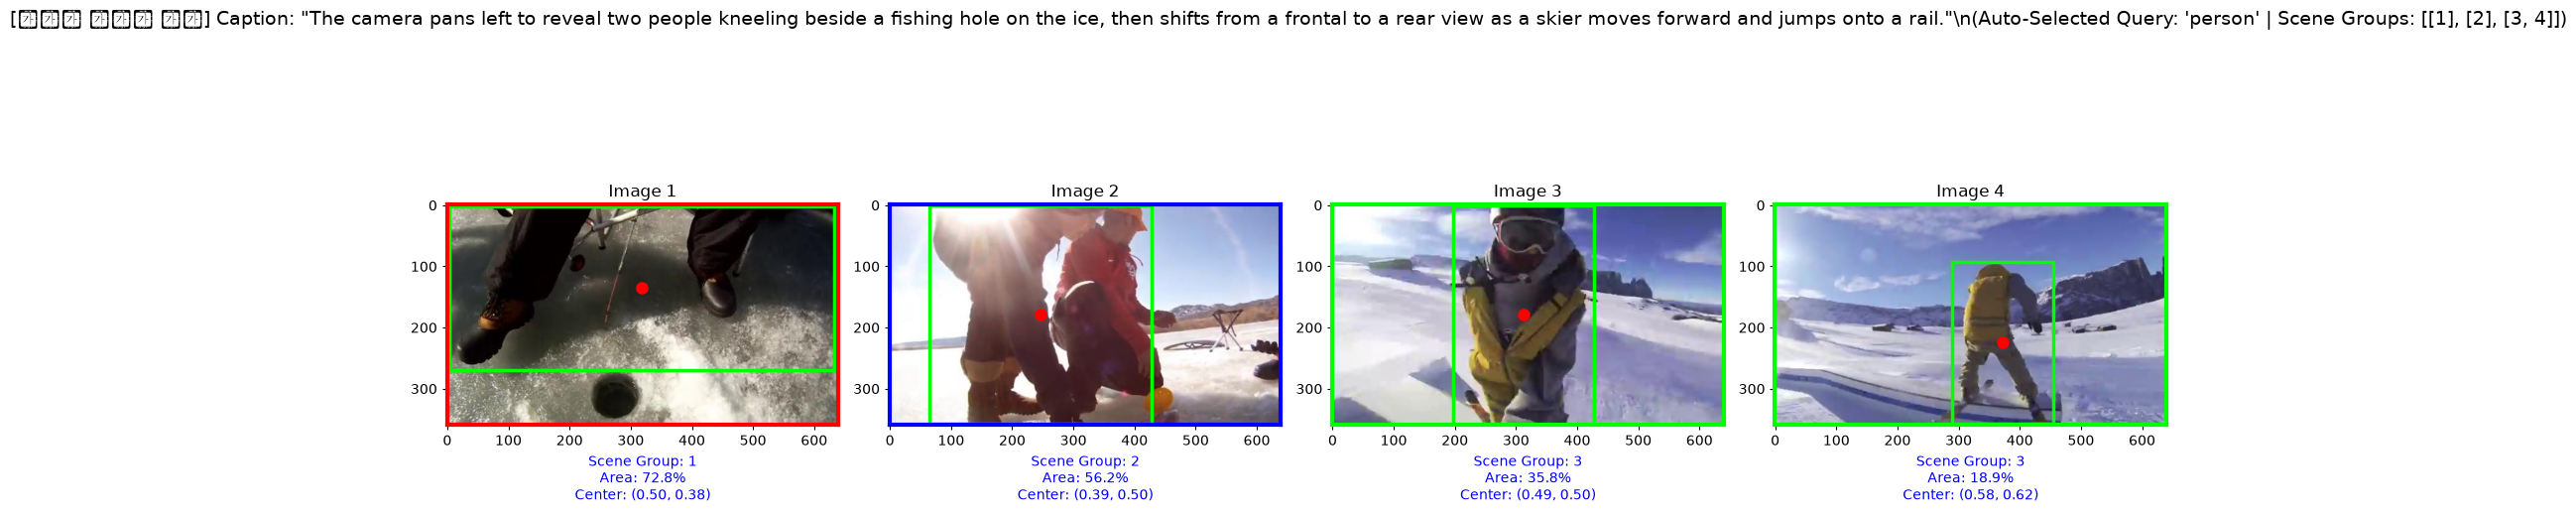

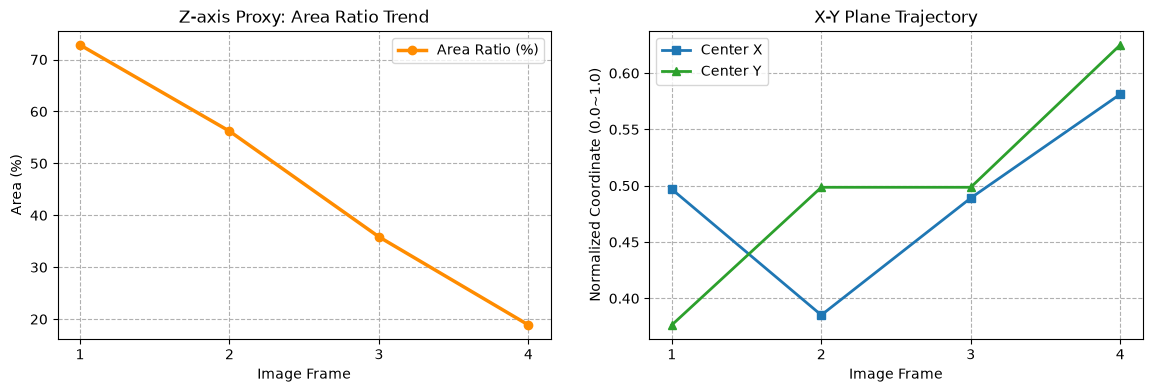

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13986.44it/s]

✅ Sentence-Transformer 모델 로드 성공!


# 📊 [IMAGE_INTEGRATION_PLAN] 최종 고도화 검증 리포트

본 리포트는 비디오 프레임 순서 정렬을 위해 **텍스트 임베딩 가중치**, **CLIP 장면 분할**, **OWL-ViT 기하 측정 데이터**를 종합적으로 분석한 검증 보고서입니다.

---
### 📝 1. 문장 의미론 및 가중치 분석 (Text Semantics)
* **분석 대상 캡션**: "The camera pans left to reveal two people kneeling beside a fishing hole on the ice, then shifts from a frontal to a rear view as a skier moves forward and jumps onto a rail."
* **기준 축별 유사도**:
  * **3D 깊이 유사도 (Depth Match)**: 0.27
  * **2D 평면 궤적 유사도 (Trajectory Match)**: 0.27
* **시스템 판단**:
  * 본 문장은 **Z-Axis (Depth/Zoom)**의 물리적 변화를 묘사하는 경향이 더 강합니다.
  * **추천 분석 전략**: **깊이 변화 흐름[주인공의 화면 점유 비율 변화]**에 가중치를 두어 프레임 순서를 판단하세요.

---
### 🎬 2. CLIP 장면 전환 분석 (Cuts Analysis)
* **프레임 간 인접 시맨틱 유사도**: [0.74, 0.82, 0.92]
* **씬 그룹핑 결과**: 3개 장면 감지
  * **Scene Group 1**: Image [1]
  * **Scene Group 2**: Image [2]
  * **Scene Group 3**: Image [3, 4]

> **장면 전환 안전 규칙**: 장면 전환 경계를 가로지르는 전체 프레임 단순 비교는 왜곡을 초래합니다. 
> 반드시 위에서 분할된 동일 장면 그룹 내부에서만 연속적인 동작이나 줌인/줌아웃을 평가해야 합니다.

---
### 🎯 3. 핵심 피사체 및 기하학적 추적 데이터 (Geometry Tracking)
* **자동 채택 피사체 쿼리**: person (평균 검출 신뢰도: 0.093)
* **프레임별 측정 결과**:
  * **Image 1 (Group 1)**: Center=[X=0.497, Y=0.376], Area=72.8%
  * **Image 2 (Group 2)**: Center=[X=0.385, Y=0.499], Area=56.2%
  * **Image 3 (Group 3)**: Center=[X=0.489, Y=0.499], Area=35.8%
  * **Image 4 (Group 3)**: Center=[X=0.581, Y=0.625], Area=18.9%

---
### 📐 4. 인과관계 해석 및 최종 정렬 가이드 (VLM Reasoning Link)
* 문장에서 **줌/깊이 변화** 묘사가 주되므로 **Area Ratio(면적 비율)** 트렌드를 절대적 단서로 삼습니다.
* **물리 법칙 매핑**: 피사체가 **줌아웃 (면적 감소)** 중이므로, 피사체 면적이 작아지는 흐름으로 연결되어야 합니다.
  * **Scene Group 3 추천 정렬 흐름**: Image 3 (35.8%) -> Image 4 (18.9%)

---
### 🏁 5. 정답지(Ground Truth) 비교 분석
* **대회 라벨 정답 순서 (셔플 인덱스)**: `[1, 2, 3, 4]`
    => 기하학적 시공간 변화 흐름이 정답 레이블 시퀀스와 완벽히 정합하는지 비교하십시오.

=========================================================================

In [57]:
csv_path = 'train.csv' if os.path.exists('train.csv') else '../train.csv'
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    # 줌 또는 카메라 관련 묘사가 담긴 행 추출
    camera_samples = df[df['Sentence'].str.contains('zoom|closer|further|camera|shot|lens|person', case=False, na=False)]
    
    if len(camera_samples) > 0:
        sample = camera_samples.iloc[0]
        print("--- 실제 데이터 샘플 로드 ---")
        print(f"Id: {sample['Id']}")
        print(f"Sentence: {sample['Sentence']}")
        print(f"Answer: {sample['Answer']}")
        
        img_dir = 'data_train' if os.path.exists('data_train') else '../data_train'
        img_dir = os.path.join(img_dir, sample['Id'])
        
        query_word = "person"
        for word in ["kayak", "scissors", "comb", "car", "dog", "cat", "ball"]:
            if word in sample['Sentence'].lower():
                query_word = word
                break
                
        if os.path.exists(img_dir):
            img_files = sorted(os.listdir(img_dir))
            full_paths = [os.path.join(img_dir, f) for f in img_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:4]
            
            # 가시화 함수 실행 및 검증 검수
            visualize_and_verify_plan(full_paths, sample['Sentence'], query_word, sample['Answer'])
        else:
            print(f"\nℹ️ 이미지 폴더 '{img_dir}'가 아직 탐색되지 않은 환경입니다. Mock 모션 모드로 가시화 검증을 실행합니다.")
            visualize_and_verify_plan(fake_images, sample['Sentence'], query_word, sample['Answer'])
    else:
        print("적절한 캡션 행을 찾지 못했습니다.")
else:
    print("⚠️ train.csv가 없습니다. 프로젝트 루트에서 구동하고 있는지 확인하세요.")